In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))
import config
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingClassifier
from src.cleaning import clean
from src.feature_engineering import build_panel_data

df = pd.read_csv(config.DB_LOCATION)
cleaned, full_history = clean(df)
panel_data, last_complete_year = build_panel_data(cleaned, full_history)

train = panel_data[panel_data['Year'] <= 2022]
validate = panel_data[panel_data['Year'] == 2023]
test = panel_data[panel_data['Year'] == 2024]

train_X = train[config.FEATURES]
train_y = train['Churns']
validate_X = validate[config.FEATURES]
validate_y = validate['Churns']
test_X = test[config.FEATURES]
test_y = test['Churns']

clf = HistGradientBoostingClassifier(
    random_state=42,
    learning_rate=config.FINAL_PARAMS['learning_rate'],
    max_depth=config.FINAL_PARAMS['max_depth'],
    max_iter=config.FINAL_PARAMS['max_iter'],
    l2_regularization=config.FINAL_PARAMS['l2_regularization']
)
clf.fit(train_X, train_y)
probs = clf.predict_proba(test_X)[:, 1]

C:\Users\bnpar\AppData\Local\Temp\ipykernel_27984\965240600.py:12: DtypeWarning: Columns (33,38) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(config.DB_LOCATION)


In [2]:
from sklearn.frozen import FrozenEstimator
from sklearn.calibration import CalibratedClassifierCV
calibrated_clf = CalibratedClassifierCV(FrozenEstimator(clf), method='sigmoid')
calibrated_clf.fit(validate_X, validate_y)
probs = calibrated_clf.predict_proba(test_X)[:, 1]



The optimal threshold $p = t^*$ above which retention interventions should be applied can be determined by examining expected profit. 
The retention intervention takes the form of a half-price one-on-one coaching session if the lifter signs up for the next year's membership. The net cost of each coaching session to the federation is then
$$C = C_{\text{run session}} - \frac{1}{2} \text{Price}_{\text{session}}$$

and the expected revenue is then $$\text{revenue} =  P(\text{stay} \mid \text{intervention}) \cdot N_{p > t} \cdot (V - C) + \sum_{p_i < t} (1 - p_i)  \cdot V$$
where:
- $V$ is the value of a retained lifter, assumed equal across lifters
- $C$ is the net cost of the coaching session to the federation
- $t$ is the intervention threshold
- $N_{p > t}$ is the number of lifters with predicted churn probability above $t$
- $p_i$ is the predicted churn probability for lifter $i$
- $P(\text{stay} \mid \text{intervention})$ is the probability a lifter is retained given intervention, assumed constant across lifters and estimable via A/B test

$$t^* = \underset{t \in [0,1]}{\arg\max} \left[ P(\text{stay} \mid \text{intervention}) \cdot N_{p > t} \cdot (V - C) + \sum_{p_i < t} (1 - p_i) \cdot V \right]$$

The optimal threshold $t^*$ maximises expected profit. Since the relationship between $t$ and profit depends on the empirical distribution of predicted probabilities, this would be found via searching over values of $t$ rather than analytically.


In [3]:
V = 50
C = 10
p_retention = 0.35

thresholds = np.arange(0, 1.01, 0.01)
revenues = []

for t in thresholds:
    intervene = probs > t
    n_intervene = intervene.sum()
    revenue_intervened = p_retention * n_intervene * (V - C)
    revenue_not_intervened = np.sum((1 - probs[~intervene]) * V)
    revenues.append(revenue_intervened + revenue_not_intervened)

revenues = np.array(revenues)
t_star = thresholds[np.argmax(revenues)]

In [4]:
print(f'Optimal threshold t* = {t_star:.2f}')
print(f'Revenue at t* = £{revenues.max():,.0f}')
print(f'Revenue at t=0.5 = £{revenues[thresholds == 0.5][0]:,.0f}')
print(f'Revenue at t=0 = £{revenues[thresholds == 0][0]:,.0f}')
print(f'Revenue at t=1 = £{revenues[thresholds == 1][0]:,.0f}')

Optimal threshold t* = 0.72
Revenue at t* = £1,011,237
Revenue at t=0.5 = £928,014
Revenue at t=0 = £573,342
Revenue at t=1 = £998,730


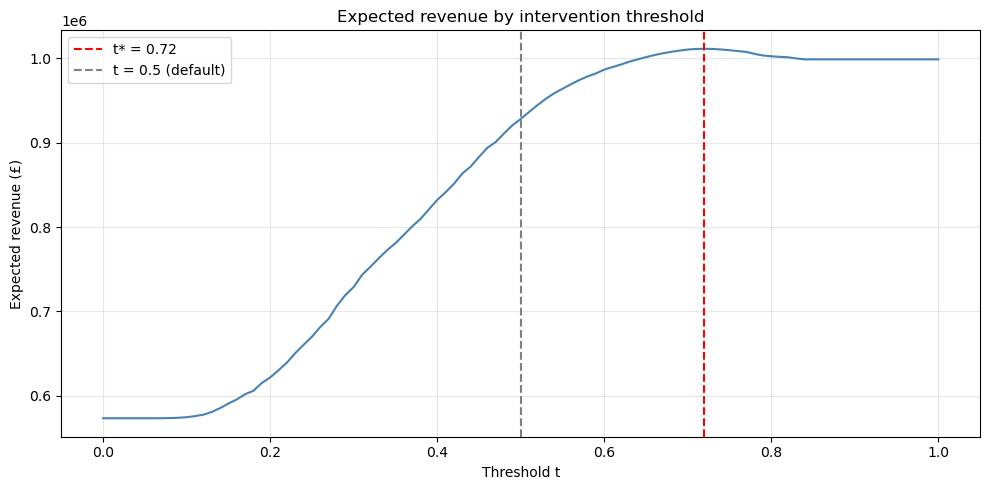

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(thresholds, revenues, color='steelblue')
plt.axvline(t_star, color='red', linestyle='--', label=f't* = {t_star:.2f}')
plt.axvline(0.5, color='gray', linestyle='--', label='t = 0.5 (default)')
plt.xlabel('Threshold t')
plt.ylabel('Expected revenue (£)')
plt.title('Expected revenue by intervention threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
rev_no_intervention = np.sum(test_y == 0) * V
print(f'Actual 2024 revenue: £{rev_no_intervention:,.0f}')

Actual 2024 revenue: £983,250
